In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
 df = pd.read_csv("/content/linear_regression_business_dataset.csv")

In [ ]:
df.shape

(150, 3)

In [ ]:
df.head()

,digital_marketing_spend,store_visitors,sales_revenue
0,20795,995,33508
1,5860,1251,32773
2,43158,1843,63628
3,49732,1779,59334
4,16284,1563,46277


In [ ]:
x = df[['digital_marketing_spend','store_visitors']]
y = df['sales_revenue']

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [ ]:
prediction = model.predict([[60,40]])
prediction

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3103.59100368])

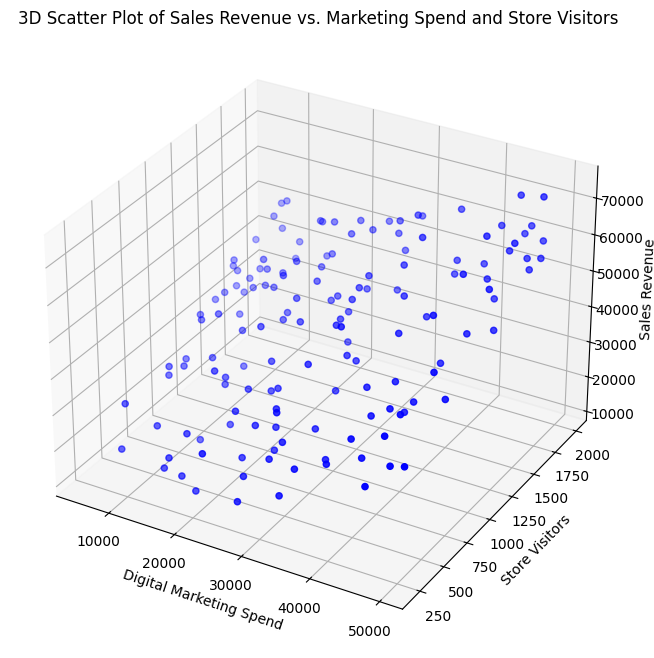

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x['digital_marketing_spend'], x['store_visitors'], y, c='blue', marker='o')

ax.set_xlabel('Digital Marketing Spend')
ax.set_ylabel('Store Visitors')
ax.set_zlabel('Sales Revenue')
ax.set_title('3D Scatter Plot of Sales Revenue vs. Marketing Spend and Store Visitors')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_290/1417304340.py:33: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  ax.legend(handles=handles, labels=labels)


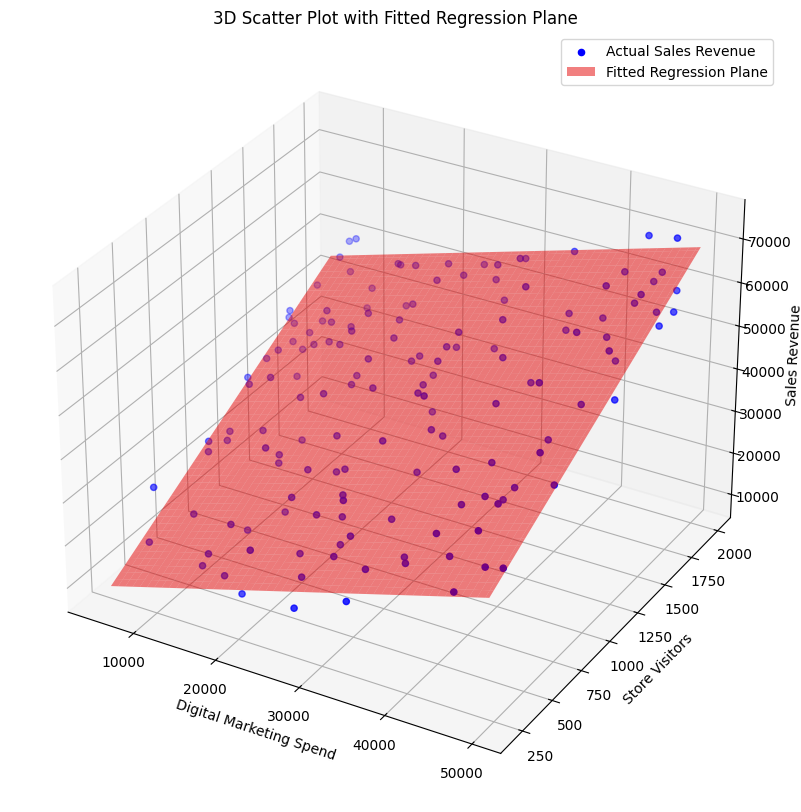

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd # Import pandas for DataFrame creation

# Create a figure and a 3D subplot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data points
ax.scatter(x['digital_marketing_spend'], x['store_visitors'], y, c='blue', marker='o', label='Actual Sales Revenue')

# Create a meshgrid for the input features
# We'll use the range of the existing data for these features

x_surf, y_surf = np.meshgrid(np.linspace(x['digital_marketing_spend'].min(), x['digital_marketing_spend'].max(), 100),
                             np.linspace(x['store_visitors'].min(), x['store_visitors'].max(), 100))

# Predict sales revenue for each point in the meshgrid
# To avoid the UserWarning, create a DataFrame with feature names
predict_df = pd.DataFrame(np.array([x_surf.ravel(), y_surf.ravel()]).T,
                          columns=['digital_marketing_spend', 'store_visitors'])
z_surf = model.predict(predict_df).reshape(x_surf.shape)

# Plot the regression surface
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.5)

# Set labels and title
ax.set_xlabel('Digital Marketing Spend')
ax.set_ylabel('Store Visitors')
ax.set_zlabel('Sales Revenue')
ax.set_title('3D Scatter Plot with Fitted Regression Plane')

# Create a dummy element for the legend for the surface plot
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(color='red', alpha=0.5))
labels.append('Fitted Regression Plane') # Add corresponding label for the patch
ax.legend(handles=handles, labels=labels)

plt.show()